In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                             accuracy_score, roc_auc_score, average_precision_score, 
                             confusion_matrix)
import lightgbm as lgb
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns


## Opis kroków przeprowadzonych podczas estymacji oraz walidacji modelu Light GBM:
### Wczytanie danych
Dane na których został wytrenowany oraz zwalidowany model Lasów Losowych to dane, dla których została przeprowadzaona Ekspolarcyjna Analiza Danych oraz Inżynieria Cech w Notebooku `00_EAD`.
Wczytane dane zostały już wcześniej podzielone na zbiór treningowy oraz testowy w proporcji 30/70.

### Transformacja danych
Następnie została przeprowadzona transformacja danych:
- One-Hot Encoding: zmienna określająca rodzaj transakcji `type` jest zmienną kategoryczną. Częśc z wykorzystanych samplerów w badaniu opartych jest na odległościach, zatem w ich przypadku wymagane są dane numeryczne. 
- RobustScaler: podobnie jak w przypadku zastosowania metody One-Hot Encoding, samplery oprate na odległości wymagają danych, które mają taką samą skale.
Jako skaler użyto RobustSkaler, który jest bardziej odporny na wartości odstające, które występują w danych finansowych. Został on zastosowany do wszystkich kolumn, poza kolumnami 0/1.
W przypadku modelu Lasów Losowych skalowanie danych nie wpływa w żaden sposób na jego estymowanie.

$$X_{scaled} = \frac{X - \text{median}(X)}{IQR(X)} = \frac{X - \text{median}(X)}{Q_3(X) - Q_1(X)}$$

* $\text{median}(X)$ – medianę dla danej cechy wyliczoną z całego zbioru treningowego.
* $IQR(X)$ – rozstęp międzykwartylowy, będący miarą rozproszenia danych.
* $Q_1(X)$ – pierwszy kwartyl,
* $Q_3(X)$ – trzeci kwartyl,

**Dla modelu bazowego oraz samplerów, które nie są oparte na odległościach wykorzystano dane surowe, bez wykorzystania one-hot encoding oraz skalowania.**

### Słownik sampletrów
W następnym bloku zdefiniowano słownik `samplers` przygotowujący środowisko do eksperymentów z balansowaniem klas. 
Skrypt iteracyjnie generuje zestaw obejmujący wariant bazowy oraz 6 algorytmów: RandomUnderSampler, Cluster Centroids, RandomOverSampler, SMOTE, Borderline-SMOTE, ADASYN. 
Każda z metod jest inicjalizowana dla 4 różnych docelowych proporcji klasy mniejszościowej: 0.25, 0.50, 0.75 oraz 1.0.

### Główna pętla
Finalnie uruchamiana jest główna pętla eksperymentu. 
Kod iteruje przez zdefiniowany wcześniej słownik samplerów, przekształcając zbiór treningowy i trenując na nim standardowy model Light GBM. 
Następnie trenowany jest osobny model wykorzystujący wbudowane ważenie klas `class_weight='balanced'`, testując podejście na poziomie algorytmu. 
Dla każdego wariantu obliczane są kluczowe metryki na zbiorze treningowym jak i testowym.

### Analiza przesunięcia ważności cech
Następnie została przprowadzona analiza ważności cech dla wybranych metod. 


### Wczytanie danych

In [2]:
X_train = pd.read_parquet('gotowe_dane/X_train.parquet')
X_test = pd.read_parquet('gotowe_dane/X_test.parquet')
y_train = pd.read_parquet('gotowe_dane/y_train.parquet')['isFraud']
y_test = pd.read_parquet('gotowe_dane/y_test.parquet')['isFraud']

### Transformacja danych

In [3]:
# One-Hot Encoding dla kolumny kategorycznej
X_train_ohe = pd.get_dummies(X_train, columns=['type'], drop_first=True, dtype=int)
X_test_ohe = pd.get_dummies(X_test, columns=['type'], drop_first=True, dtype=int)

# Zbieramy kolumny numeryczne
num_cols = [col for col in X_train.columns if col != 'type']

X_train_scaled = X_train_ohe.copy()
X_test_scaled = X_test_ohe.copy()

# RobustScaler tylko na kolumnach numerycznych, z pominięciem kolumn 0/1
scaler = RobustScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_ohe[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_ohe[num_cols])

### Definiowanie słownika samplerów

In [4]:
proporcje = [0.25, 0.5, 0.75, 1.0]
samplers = {'Model bazowy': None}

for p in proporcje:
    nazwa_p = str(p)
    samplers[f'RUS ({nazwa_p})'] = RandomUnderSampler(sampling_strategy=p, random_state=42)
    samplers[f'ROS ({nazwa_p})'] = RandomOverSampler(sampling_strategy=p, random_state=42)
    samplers[f'SMOTE ({nazwa_p})'] = SMOTE(sampling_strategy=p, random_state=42)
    samplers[f'Borderline-SMOTE ({nazwa_p})'] = BorderlineSMOTE(sampling_strategy=p, random_state=42)
    samplers[f'ADASYN ({nazwa_p})'] = ADASYN(sampling_strategy=p, random_state=42)
    
    samplers[f'Cluster Centroids ({nazwa_p})'] = ClusterCentroids(
        sampling_strategy=p,
        estimator=MiniBatchKMeans(n_init=1, random_state=42), 
        random_state=42
    )

### Główna pętla

In [5]:
base_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,      
    'n_jobs': -1,              
    'random_state': 42
}

model_standard = lgb.LGBMClassifier(**base_params)
model_weighted = lgb.LGBMClassifier(**base_params, class_weight='balanced')

results_train = []
results_test = []
print("\n--- ROZPOCZĘCIE EKSPERYMENTU: LIGHTGBM ---")

for s_name, sampler in samplers.items():
    print(f" -> Trenuję: LightGBM + {s_name}")
    
    # wybieramy odpowiednie dane, model Light_GBM nie wymaga zmiany danych kategorycznych na zmienne binarne, zatem wybieramy je tylko w momencie gdy sampler tego wymaga (opiera sie na odlegosciach)
    # zatem w przypadku modelu opartego na czystych, niezbalansowanych danych, przy samplerach RUS i ROS oraz przy podejściu balanoswania na poziomie modelu 
    # wybieramy dane bez one-hot oraz bez skalowania,
    if any(keyword in s_name for keyword in ['SMOTE', 'ADASYN', 'Cluster']):
        X_train_current = X_train_scaled
        X_test_current = X_test_scaled
    else:
        X_train_current = X_train
        X_test_current = X_test

    # timer dla samplera   
    start_sampler = time.time()
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train_current, y_train)
    else:
        X_res, y_res = X_train_current, y_train
    end_sampler = time.time()
    czas_samplera = end_sampler - start_sampler

    # timer dla modelu
    start_model = time.time()
    model_standard.fit(X_res, y_res)
    end_model = time.time()
    czas_modelu = end_model - start_model
    
    czas_calkowity = czas_samplera + czas_modelu
    
    # ZBIÓR TESTOWY
    preds_test = model_standard.predict(X_test_current)
    preds_proba_test = model_standard.predict_proba(X_test_current)[:, 1]
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, preds_test).ravel()
    
    # ZBIÓR TRENINGOWY
    preds_train = model_standard.predict(X_train_current)
    preds_proba_train = model_standard.predict_proba(X_train_current)[:, 1]
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, preds_train).ravel()
    
    # ZAPIS DO TABELI TESTOWEJ
    results_test.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_test, preds_test),
        'Precision (Precyzja)': precision_score(y_test, preds_test),
        'F1-Score': f1_score(y_test, preds_test),
        'ROC-AUC': roc_auc_score(y_test, preds_proba_test),
        'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test),
        'Accuracy': accuracy_score(y_test, preds_test),
        'Fałszywe Alarmy (FP)': fp_test,
        'Przegapione Oszustwa (FN)': fn_test
    })
        
    # ZAPIS DO TABELI TRENINGOWEJ
    results_train.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_train, preds_train),
        'Precision (Precyzja)': precision_score(y_train, preds_train),
        'F1-Score': f1_score(y_train, preds_train),
        'ROC-AUC': roc_auc_score(y_train, preds_proba_train),
        'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train),
        'Accuracy': accuracy_score(y_train, preds_train),
        'Fałszywe Alarmy (FP)': fp_train,
        'Przegapione Oszustwa (FN)': fn_train
    })

# wewnętrzne ważenie klas
print(" -> Trenuję: LightGBM + Wewnętrzne Wagi (class_weight='balanced')")

czas_samplera_w = 0.0

# timer dla modelu
start_model_w = time.time()
model_weighted.fit(X_train, y_train)
end_model_w = time.time()
czas_modelu_w = end_model_w - start_model_w

czas_calkowity_w = czas_samplera_w + czas_modelu_w

# ZBIÓR TESTOWY
preds_test_w = model_weighted.predict(X_test)
preds_proba_test_w = model_weighted.predict_proba(X_test)[:, 1]
tn_test_w, fp_test_w, fn_test_w, tp_test_w = confusion_matrix(y_test, preds_test_w).ravel()

# ZBIÓR TRENINGOWY
preds_train_w = model_weighted.predict(X_train)
preds_proba_train_w = model_weighted.predict_proba(X_train)[:, 1]
tn_train_w, fp_train_w, fn_train_w, tp_train_w = confusion_matrix(y_train, preds_train_w).ravel()

# ZAPIS DO TABELI TESTOWEJ
results_test.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_test, preds_test_w),
    'Precision (Precyzja)': precision_score(y_test, preds_test_w),
    'F1-Score': f1_score(y_test, preds_test_w),
    'ROC-AUC': roc_auc_score(y_test, preds_proba_test_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test_w),
    'Accuracy': accuracy_score(y_test, preds_test_w),
    'Fałszywe Alarmy (FP)': fp_test_w,
    'Przegapione Oszustwa (FN)': fn_test_w
})

# ZAPIS DO TABELI TRENINGOWEJ
results_train.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_train, preds_train_w),
    'Precision (Precyzja)': precision_score(y_train, preds_train_w),
    'F1-Score': f1_score(y_train, preds_train_w),
    'ROC-AUC': roc_auc_score(y_train, preds_proba_train_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train_w),
    'Accuracy': accuracy_score(y_train, preds_train_w),
    'Fałszywe Alarmy (FP)': fp_train_w,
    'Przegapione Oszustwa (FN)': fn_train_w
})

print("\n--- ZAKOŃCZONO ---")

results_df_train = pd.DataFrame(results_train)
results_df_test = pd.DataFrame(results_test)

nazwa_pliku_train = 'wyniki_lightgbm_train.csv'
nazwa_pliku_test = 'wyniki_lightgbm_test.csv'

# results_df_train.to_csv(nazwa_pliku_train, index=False)
# results_df_test.to_csv(nazwa_pliku_test, index=False)

# print(f"Wyniki treningowe zostały zapisane do pliku: {nazwa_pliku_train}")
# print(f"Wyniki testowe zostały zapisane do pliku: {nazwa_pliku_test}")



--- ROZPOCZĘCIE EKSPERYMENTU: LIGHTGBM ---
 -> Trenuję: LightGBM + Model bazowy
[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651203
[LightGBM] [Info] Start training from score -6.651203
 -> Trenuję: LightGBM + RUS (0.25)
[LightGBM] [Info] Number of positive: 5749, number of negative: 22996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 

In [6]:
display(results_df_train)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Model bazowy,0.00,5.65,5.65,0.798574,0.091651,0.164431,0.884987,0.469190,0.989524,45501,1158
1,Data-Level,RUS (0.25),0.56,0.50,1.06,1.000000,0.878380,0.935253,1.000000,0.999336,0.999821,796,0
2,Data-Level,ROS (0.25),2.20,6.82,9.01,1.000000,0.993605,0.996792,1.000000,0.999998,0.999992,37,0
3,Data-Level,SMOTE (0.25),1.34,7.08,8.42,0.996695,0.996175,0.996435,0.997369,0.995049,0.999991,22,19
4,Data-Level,Borderline-SMOTE (0.25),5.45,6.44,11.88,0.990607,0.936062,0.962562,0.993045,0.853426,0.999901,389,54
5,Data-Level,ADASYN (0.25),5.41,7.04,12.45,0.996695,0.996868,0.996782,0.997548,0.995051,0.999992,18,19
6,Data-Level,Cluster Centroids (0.25),288.82,0.62,289.44,1.000000,0.917052,0.956732,1.000000,0.999889,0.999883,520,0
7,Data-Level,RUS (0.5),0.70,0.45,1.15,1.000000,0.813845,0.897370,1.000000,0.999665,0.999705,1315,0
8,Data-Level,ROS (0.5),2.97,8.21,11.18,1.000000,0.990865,0.995412,1.000000,0.999997,0.999988,53,0
9,Data-Level,SMOTE (0.5),1.56,8.03,9.58,0.996347,0.979313,0.987757,0.997900,0.971607,0.999968,121,21


In [7]:
display(results_df_test)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Model bazowy,0.00,5.65,5.65,0.776380,0.090552,0.162187,0.872677,0.449863,0.989646,19213,551
1,Data-Level,RUS (0.25),0.56,0.50,1.06,0.996753,0.888246,0.939377,0.999775,0.997585,0.999834,309,8
2,Data-Level,ROS (0.25),2.20,6.82,9.01,0.996347,0.995539,0.995943,0.999505,0.997832,0.999990,11,9
3,Data-Level,SMOTE (0.25),1.34,7.08,8.42,0.996347,0.990718,0.993525,0.997918,0.987977,0.999983,23,9
4,Data-Level,Borderline-SMOTE (0.25),5.45,6.44,11.88,0.991071,0.934916,0.962175,0.994056,0.851965,0.999899,170,22
5,Data-Level,ADASYN (0.25),5.41,7.04,12.45,0.995536,0.987520,0.991512,0.996804,0.980629,0.999978,31,11
6,Data-Level,Cluster Centroids (0.25),288.82,0.62,289.44,0.997159,0.928571,0.961644,0.999804,0.997453,0.999897,189,7
7,Data-Level,RUS (0.5),0.70,0.45,1.15,0.997565,0.812293,0.895446,0.999677,0.998243,0.999699,568,6
8,Data-Level,ROS (0.5),2.97,8.21,11.18,0.996347,0.994733,0.995539,0.999728,0.997857,0.999988,13,9
9,Data-Level,SMOTE (0.5),1.56,8.03,9.58,0.994724,0.964581,0.979421,0.996970,0.952171,0.999946,90,13


### Podejście drugie - zwiększona liczba drzew + early_stopping

Domyślnie LightGBM buduje drzewa tak długo, aż wyczerpie limit iteracji. W naszym eksperymencie zastosowano poniższy zabieg:
- Po dodaniu każdego nowego drzewa model jest testowany na zbiorze walidacyjnym za pomocą F1-Score (funkcja lgb_f1_score).
- Metryka F1 bezwzględnie karze model zarówno za fałszywe alarmy (spadek precyzji), jak i za przegapione oszustwa (spadek czułości).
- Kiedy F1-Score osiąga swoje absolutne maksimum i przez kolejne 30 rund nie potrafi już wzrosnąć, trening zostaje przerwany.

In [8]:
# metryka F1 dla 
def lgb_f1_score(y_true, y_pred_proba):
    y_pred = np.where(y_pred_proba >= 0.5, 1, 0)
    # Zwraca: (nazwa_metryki, wartość, czy_wyższa_wartość_jest_lepsza)
    return 'f1', f1_score(y_true, y_pred, zero_division=0), True

# zwiększamy n_estimators do 2000 i zmniejszamy learning_rate
# early_stopping sam znajdzie idealny moment zatrzymania
base_params = {
    'n_estimators': 2000,
    'learning_rate': 0.05,      
    'n_jobs': -1,              
    'random_state': 42
}

model_standard = lgb.LGBMClassifier(**base_params)
model_weighted = lgb.LGBMClassifier(**base_params, class_weight='balanced')

results_train = []
results_test = []
print("\n--- ROZPOCZĘCIE EKSPERYMENTU: LIGHTGBM (Z EARLY STOPPING NA F1) ---")

for s_name, sampler in samplers.items():
    print(f" -> Trenuję: LightGBM + {s_name}")
    
    # wybieramy odpowiednie dane, model Light_GBM nie wymaga zmiany danych kategorycznych na zmienne binarne, zatem wybieramy je tylko w momencie gdy sampler tego wymaga (opiera sie na odlegosciach)
    # zatem w przypadku modelu opartego na czystych, niezbalansowanych danych, przy samplerach RUS i ROS oraz przy podejściu balanoswania na poziomie modelu 
    # wybieramy dane bez one-hot oraz bez skalowania,
    if any(keyword in s_name for keyword in ['SMOTE', 'ADASYN', 'Cluster']):
        X_train_current = X_train_scaled
        X_test_current = X_test_scaled
    else:
        X_train_current = X_train
        X_test_current = X_test

    # timer dla samplera   
    start_sampler = time.time()
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train_current, y_train)
    else:
        X_res, y_res = X_train_current, y_train
    end_sampler = time.time()
    czas_samplera = end_sampler - start_sampler

    # timer dla modelu - MODYFIKACJA Z EARLY STOPPING
    start_model = time.time()
    model_standard.fit(
        X_res, y_res,
        eval_set=[(X_test_current, y_test)],        
        eval_metric=lgb_f1_score,                   
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),  
            lgb.log_evaluation(period=0)           
        ]
    )
    end_model = time.time()
    czas_modelu = end_model - start_model
    
    czas_calkowity = czas_samplera + czas_modelu
    print(f"Zatrzymano na rundzie drzewie: {model_standard.best_iteration_}")
    
    # ZBIÓR TESTOWY
    preds_test = model_standard.predict(X_test_current)
    preds_proba_test = model_standard.predict_proba(X_test_current)[:, 1]
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, preds_test).ravel()
    
    # ZBIÓR TRENINGOWY
    preds_train = model_standard.predict(X_train_current)
    preds_proba_train = model_standard.predict_proba(X_train_current)[:, 1]
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, preds_train).ravel()
    
    # ZAPIS DO TABELI TESTOWEJ
    results_test.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_test, preds_test),
        'Precision (Precyzja)': precision_score(y_test, preds_test),
        'F1-Score': f1_score(y_test, preds_test),
        'ROC-AUC': roc_auc_score(y_test, preds_proba_test),
        'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test),
        'Accuracy': accuracy_score(y_test, preds_test),
        'Fałszywe Alarmy (FP)': fp_test,
        'Przegapione Oszustwa (FN)': fn_test
    })
        
    # ZAPIS DO TABELI TRENINGOWEJ
    results_train.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_train, preds_train),
        'Precision (Precyzja)': precision_score(y_train, preds_train),
        'F1-Score': f1_score(y_train, preds_train),
        'ROC-AUC': roc_auc_score(y_train, preds_proba_train),
        'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train),
        'Accuracy': accuracy_score(y_train, preds_train),
        'Fałszywe Alarmy (FP)': fp_train,
        'Przegapione Oszustwa (FN)': fn_train
    })

# wewnętrzne ważenie klas
print(" -> Trenuję: LightGBM + Wewnętrzne Wagi (class_weight='balanced')")

czas_samplera_w = 0.0

# timer dla modelu - MODYFIKACJA Z EARLY STOPPING
start_model_w = time.time()
model_weighted.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],                    
    eval_metric=lgb_f1_score,                       
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)
end_model_w = time.time()
czas_modelu_w = end_model_w - start_model_w

czas_calkowity_w = czas_samplera_w + czas_modelu_w

# ZBIÓR TESTOWY
preds_test_w = model_weighted.predict(X_test)
preds_proba_test_w = model_weighted.predict_proba(X_test)[:, 1]
tn_test_w, fp_test_w, fn_test_w, tp_test_w = confusion_matrix(y_test, preds_test_w).ravel()

# ZBIÓR TRENINGOWY
preds_train_w = model_weighted.predict(X_train)
preds_proba_train_w = model_weighted.predict_proba(X_train)[:, 1]
tn_train_w, fp_train_w, fn_train_w, tp_train_w = confusion_matrix(y_train, preds_train_w).ravel()

# ZAPIS DO TABELI TESTOWEJ
results_test.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_test, preds_test_w),
    'Precision (Precyzja)': precision_score(y_test, preds_test_w),
    'F1-Score': f1_score(y_test, preds_test_w),
    'ROC-AUC': roc_auc_score(y_test, preds_proba_test_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test_w),
    'Accuracy': accuracy_score(y_test, preds_test_w),
    'Fałszywe Alarmy (FP)': fp_test_w,
    'Przegapione Oszustwa (FN)': fn_test_w
})

# ZAPIS DO TABELI TRENINGOWEJ
results_train.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Wagi',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_train, preds_train_w),
    'Precision (Precyzja)': precision_score(y_train, preds_train_w),
    'F1-Score': f1_score(y_train, preds_train_w),
    'ROC-AUC': roc_auc_score(y_train, preds_proba_train_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train_w),
    'Accuracy': accuracy_score(y_train, preds_train_w),
    'Fałszywe Alarmy (FP)': fp_train_w,
    'Przegapione Oszustwa (FN)': fn_train_w
})

print("\n--- ZAKOŃCZONO ---")

results_df_train = pd.DataFrame(results_train)
results_df_test = pd.DataFrame(results_test)

nazwa_pliku_train = 'wyniki_lightgbm_train.csv'
nazwa_pliku_test = 'wyniki_lightgbm_test.csv'

results_df_train.to_csv(nazwa_pliku_train, index=False)
results_df_test.to_csv(nazwa_pliku_test, index=False)

print(f"Wyniki treningowe zostały zapisane do pliku: {nazwa_pliku_train}")
print(f"Wyniki testowe zostały zapisane do pliku: {nazwa_pliku_test}")


--- ROZPOCZĘCIE EKSPERYMENTU: LIGHTGBM (Z EARLY STOPPING NA F1) ---
 -> Trenuję: LightGBM + Model bazowy
[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651203
[LightGBM] [Info] Start training from score -6.651203
Zatrzymano na rundzie drzewie: 33
 -> Trenuję: LightGBM + RUS (0.25)
[LightGBM] [Info] Number of positive: 5749, number of negative: 22996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you c

In [9]:
display(results_df_train)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Model bazowy,0.00,32.41,32.41,0.995477,0.998778,0.997125,0.998886,0.996877,0.999993,7,26
1,Data-Level,RUS (0.25),0.53,23.06,23.59,0.993042,0.973402,0.983124,0.999863,0.971405,0.999956,156,40
2,Data-Level,ROS (0.25),2.50,20.74,23.25,0.995304,0.993575,0.994439,0.999244,0.997068,0.999986,37,27
3,Data-Level,SMOTE (0.25),1.08,20.94,22.02,0.993738,0.997904,0.995817,0.998590,0.994286,0.999989,12,36
4,Data-Level,Borderline-SMOTE (0.25),5.40,27.52,32.92,0.994434,0.997209,0.995820,0.999093,0.996747,0.999989,16,32
5,Data-Level,ADASYN (0.25),5.16,20.90,26.06,0.993216,0.998252,0.995728,0.998135,0.996400,0.999989,10,39
6,Data-Level,Cluster Centroids (0.25),279.28,26.94,306.22,0.994782,0.977106,0.985865,0.999930,0.996731,0.999963,134,30
7,Data-Level,RUS (0.5),0.55,28.34,28.89,0.995130,0.983835,0.989450,0.999948,0.984794,0.999973,94,28
8,Data-Level,ROS (0.5),2.77,19.56,22.33,0.996521,0.976146,0.986228,0.999175,0.996879,0.999964,140,20
9,Data-Level,SMOTE (0.5),1.57,19.83,21.40,0.994086,0.996513,0.995298,0.998701,0.996226,0.999988,20,34


In [10]:
display(results_df_test)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Model bazowy,0.00,32.41,32.41,0.992289,0.997552,0.994914,0.999330,0.994869,0.999987,6,19
1,Data-Level,RUS (0.25),0.53,23.06,23.59,0.994318,0.980000,0.987107,0.999325,0.978039,0.999966,50,14
2,Data-Level,ROS (0.25),2.50,20.74,23.25,0.996347,0.998373,0.997359,0.999271,0.997387,0.999993,4,9
3,Data-Level,SMOTE (0.25),1.08,20.94,22.02,0.995130,0.999592,0.997356,0.998401,0.995892,0.999993,1,12
4,Data-Level,Borderline-SMOTE (0.25),5.40,27.52,32.92,0.994318,0.999184,0.996745,0.999453,0.997186,0.999992,2,14
5,Data-Level,ADASYN (0.25),5.16,20.90,26.06,0.994318,1.000000,0.997151,0.997871,0.996346,0.999993,0,14
6,Data-Level,Cluster Centroids (0.25),279.28,26.94,306.22,0.996347,0.983574,0.989919,0.999469,0.996594,0.999974,41,9
7,Data-Level,RUS (0.5),0.55,28.34,28.89,0.996347,0.985944,0.991118,0.999794,0.985901,0.999977,35,9
8,Data-Level,ROS (0.5),2.77,19.56,22.33,0.996347,0.979258,0.987729,0.998412,0.995999,0.999968,52,9
9,Data-Level,SMOTE (0.5),1.57,19.83,21.40,0.995942,0.997561,0.996751,0.998455,0.996216,0.999992,6,10


### Analiza przesunięcia ważności cech

In [11]:
def lgb_f1_score(y_true, y_pred_proba):
    y_pred = np.where(y_pred_proba >= 0.5, 1, 0)
    return 'f1', f1_score(y_true, y_pred, zero_division=0), True

# ROS (0.25)
ros_plot = RandomOverSampler(sampling_strategy=0.25, random_state=42)
X_res_ros, y_res_ros = ros_plot.fit_resample(X_train, y_train)

# RUS (0.5)
rus_plot = RandomUnderSampler(sampling_strategy=0.50, random_state=42)
X_res_rus, y_res_rus = rus_plot.fit_resample(X_train, y_train)

# Modele dystansowe na danych po skalowaniu i One-Hot Encodingu
# ADASYN (1.0)
adasyn_plot = ADASYN(sampling_strategy=1.0, random_state=42)
X_res_adasyn, y_res_adasyn = adasyn_plot.fit_resample(X_train_scaled, y_train)

# Cluster Centroids (1.0)
cc_plot = ClusterCentroids(sampling_strategy=1.0, estimator=MiniBatchKMeans(n_init=1, random_state=42), random_state=42)
X_res_cc, y_res_cc = cc_plot.fit_resample(X_train_scaled, y_train)

print("Cluster done")
# Smote (0.5)
smote_plot = SMOTE(sampling_strategy=0.50, random_state=42)
X_res_smote, y_res_smote = smote_plot.fit_resample(X_train_scaled, y_train)

base_params = {'n_estimators': 2000, 
               'learning_rate': 0.05, 
               'n_jobs': -1, 
               'random_state': 42}
cb_list = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]

lgb_baseline = lgb.LGBMClassifier(**base_params)
lgb_weighted = lgb.LGBMClassifier(**base_params, class_weight='balanced')
lgb_ros = lgb.LGBMClassifier(**base_params)
lgb_rus = lgb.LGBMClassifier(**base_params)

lgb_adasyn = lgb.LGBMClassifier(**base_params)
lgb_cc = lgb.LGBMClassifier(**base_params)
lgb_smote = lgb.LGBMClassifier(**base_params)

lgb_baseline.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)
lgb_weighted.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)
lgb_ros.fit(X_res_ros, y_res_ros, eval_set=[(X_test, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)
lgb_rus.fit(X_res_rus, y_res_rus, eval_set=[(X_test, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)

lgb_adasyn.fit(X_res_adasyn, y_res_adasyn, eval_set=[(X_test_scaled, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)
lgb_cc.fit(X_res_cc, y_res_cc, eval_set=[(X_test_scaled, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)
lgb_smote.fit(X_res_smote, y_res_smote, eval_set=[(X_test_scaled, y_test)], eval_metric=lgb_f1_score, callbacks=cb_list)


Cluster done
[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028589 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651203
[LightGBM] [Info] Start training from score -6.651203
[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 7
[Li

LGBMClassifier(learning_rate=0.05, n_estimators=2000, n_jobs=-1,
               random_state=42)

### GAIN

GAIN mierzy sumaryczny spadek błędu modelu za każdym razem, gdy drzewo decyzyjne wykorzysta daną cechę do podziału zbioru na dwie gałęzie. Jeśli podzielenie danych warunkiem sprawia, że w jednej gałęzi zostają niemal sami oszuści, a w drugiej legalni klienci, algorytm odnotowuje ogromny zysk informacyjny.

In [12]:
list_of_dfs = []

# modele trenowane na surowych danych
models_raw = {
    'Model bazowy': lgb_baseline,
    'Wewnętrzne Wagi': lgb_weighted,
    'ROS (0.25)': lgb_ros,
    'RUS (0.50)': lgb_rus
}

for name, model in models_raw.items():
    df_tmp = pd.DataFrame({
        'Cecha': X_train.columns,
        'Ważność': model.booster_.feature_importance(importance_type='gain'),
        'Model': name
    })
    list_of_dfs.append(df_tmp)

# modele parte na odległościach
models_scaled = {
    'ADASYN (1.0)': lgb_adasyn,
    'Cluster Centroids (1.0)': lgb_cc,
    'SMOTE (0.5)': lgb_smote
}

for name, model in models_scaled.items():
    df_tmp = pd.DataFrame({
        'Cecha': X_train_scaled.columns,
        'Ważność': model.booster_.feature_importance(importance_type='gain'),
        'Model': name
    })
    list_of_dfs.append(df_tmp)

df_melted = pd.concat(list_of_dfs, ignore_index=True)

# normalizacja - dzielimy wagi cech przez ich sumę w obrębie każdego modelu osobno
df_melted['Ważność'] = df_melted.groupby('Model')['Ważność'].transform(lambda x: x / x.sum())
df_importance = df_melted.pivot(index='Cecha', columns='Model', values='Ważność').fillna(0).reset_index()

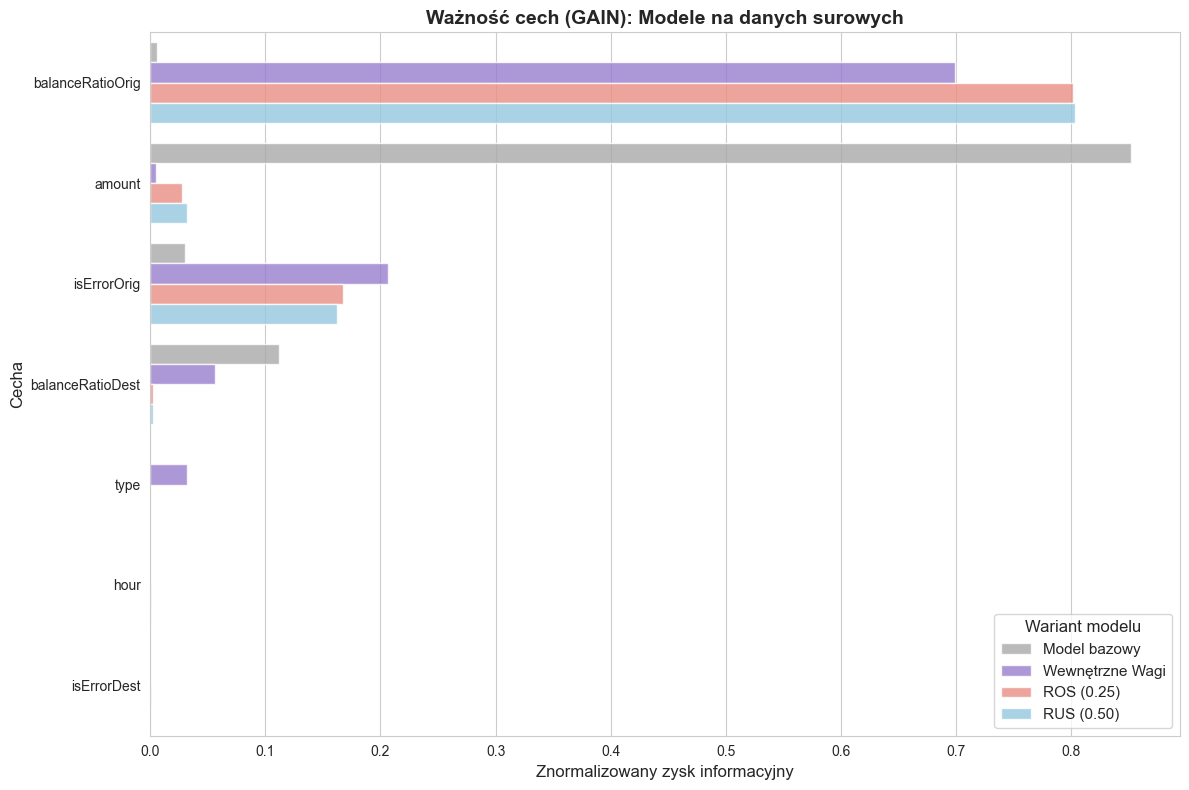

In [13]:
# wykres pierwszy 
sns.set_style("whitegrid")
df_raw_models = df_melted[df_melted['Model'].isin(models_raw.keys())]
order_raw = df_raw_models.groupby('Cecha')['Ważność'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_raw_models, 
    x='Ważność', 
    y='Cecha', 
    hue='Model', 
    order=order_raw, 
    palette=['darkgray', 'mediumpurple', 'salmon', 'skyblue'], 
    alpha=0.8
)
plt.title('Ważność cech (GAIN): Modele na danych surowych', fontsize=14, fontweight='bold')
plt.xlabel('Znormalizowany zysk informacyjny', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(title='Wariant modelu', fontsize=11, title_fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

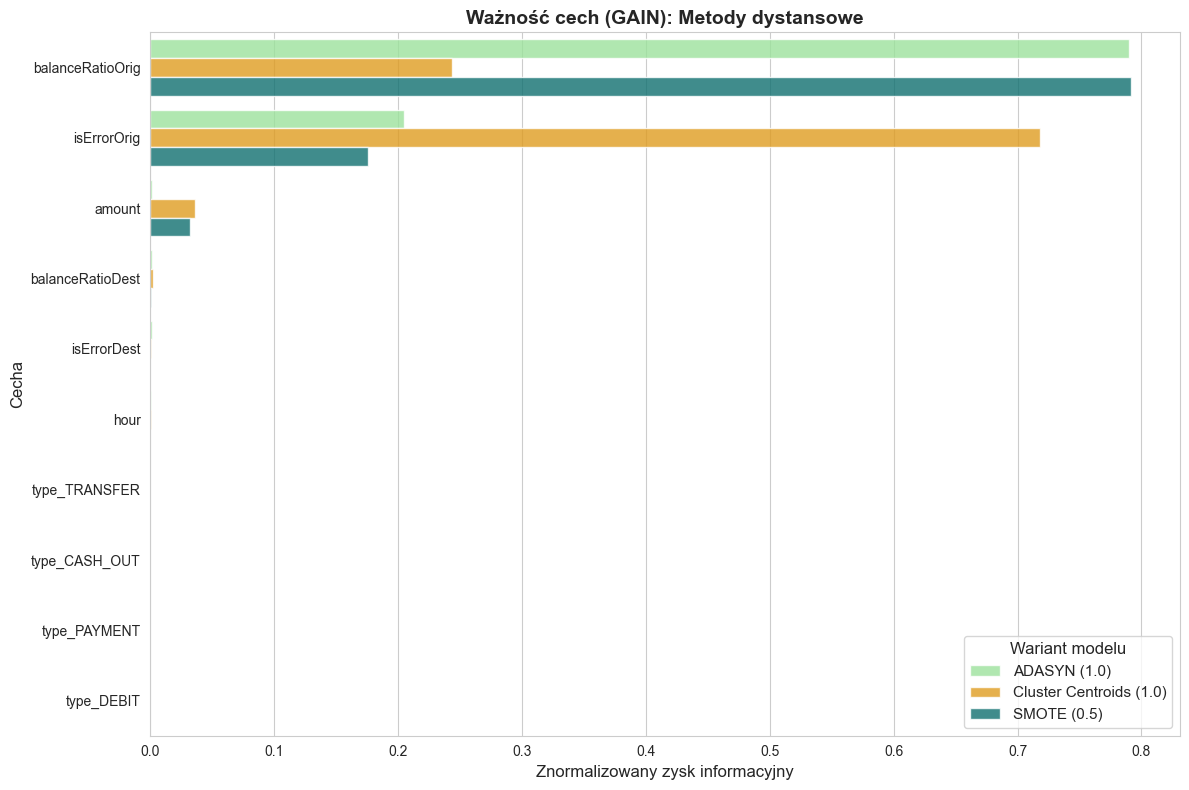

In [14]:
# wykres drugi
df_scaled_models = df_melted[df_melted['Model'].isin(models_scaled.keys())]
order_scaled = df_scaled_models.groupby('Cecha')['Ważność'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_scaled_models, 
    x='Ważność', 
    y='Cecha', 
    hue='Model', 
    order=order_scaled,
    palette=['lightgreen', 'orange', 'teal'], 
    alpha=0.8
)
plt.title('Ważność cech (GAIN): Metody dystansowe', fontsize=14, fontweight='bold')
plt.xlabel('Znormalizowany zysk informacyjny', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(title='Wariant modelu', fontsize=11, title_fontsize=12, loc='lower right')
plt.tight_layout()

### SPLIT

SPLIT zlicza, ile razy w całym zespole zbudowanych drzew (we wszystkich węzłach decyzyjnych) dana cecha została wybrana do podzielenia danych na lewe i prawe poddrzewo.

In [15]:
list_of_dfs_split = []

# modele trenowane na surowych danych
for name, model in models_raw.items():
    df_tmp = pd.DataFrame(
        {
            "Cecha": X_train.columns,
            "Ważność": model.booster_.feature_importance(
                importance_type="split"
            ),
            "Model": name,
        }
    )
    list_of_dfs_split.append(df_tmp)

# modele oparte na odleglosciach
for name, model in models_scaled.items():
    df_tmp = pd.DataFrame(
        {
            "Cecha": X_train_scaled.columns,
            "Ważność": model.booster_.feature_importance(
                importance_type="split"
            ),
            "Model": name,
        }
    )
    list_of_dfs_split.append(df_tmp)

df_melted_split = pd.concat(list_of_dfs_split, ignore_index=True)
# normalizacja - obliczamy jaki procent wszystkich podziałów w danym modelu przypada na konkretną cechę
df_melted_split["Ważność"] = df_melted_split.groupby("Model")[
    "Ważność"
].transform(lambda x: x / x.sum() if x.sum() > 0 else x)

df_importance_split = (df_melted_split.pivot(index="Cecha", columns="Model", values="Ważność").fillna(0).reset_index())


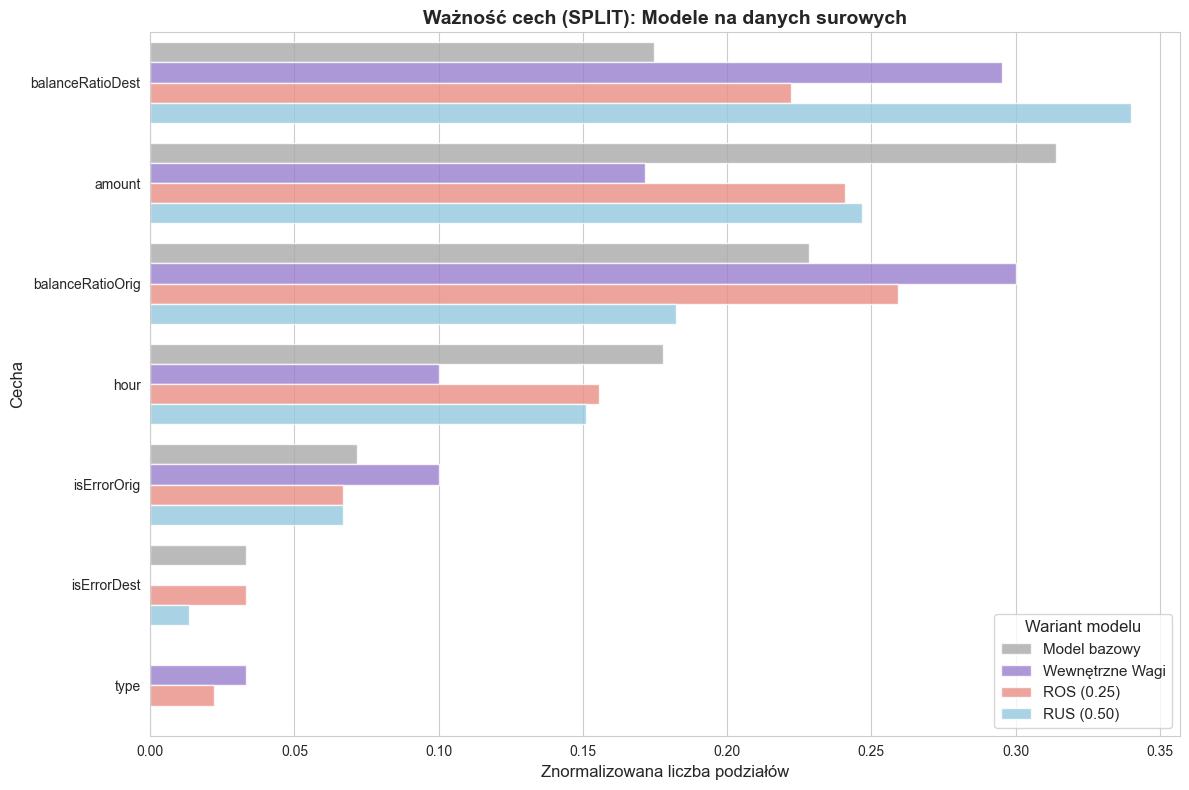

In [16]:
# wykres pierwszy
sns.set_style("whitegrid")
df_raw_split = df_melted_split[df_melted_split["Model"].isin(models_raw.keys())]
order_raw_split = (
    df_raw_split.groupby("Cecha")["Ważność"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_raw_split,
    x="Ważność",
    y="Cecha",
    hue="Model",
    order=order_raw_split,
    palette=["darkgray", "mediumpurple", "salmon", "skyblue"],
    alpha=0.8,
)
plt.title('Ważność cech (SPLIT): Modele na danych surowych', fontsize=14, fontweight="bold")
plt.xlabel('Znormalizowana liczba podziałów', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(title='Wariant modelu', fontsize=11, title_fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()


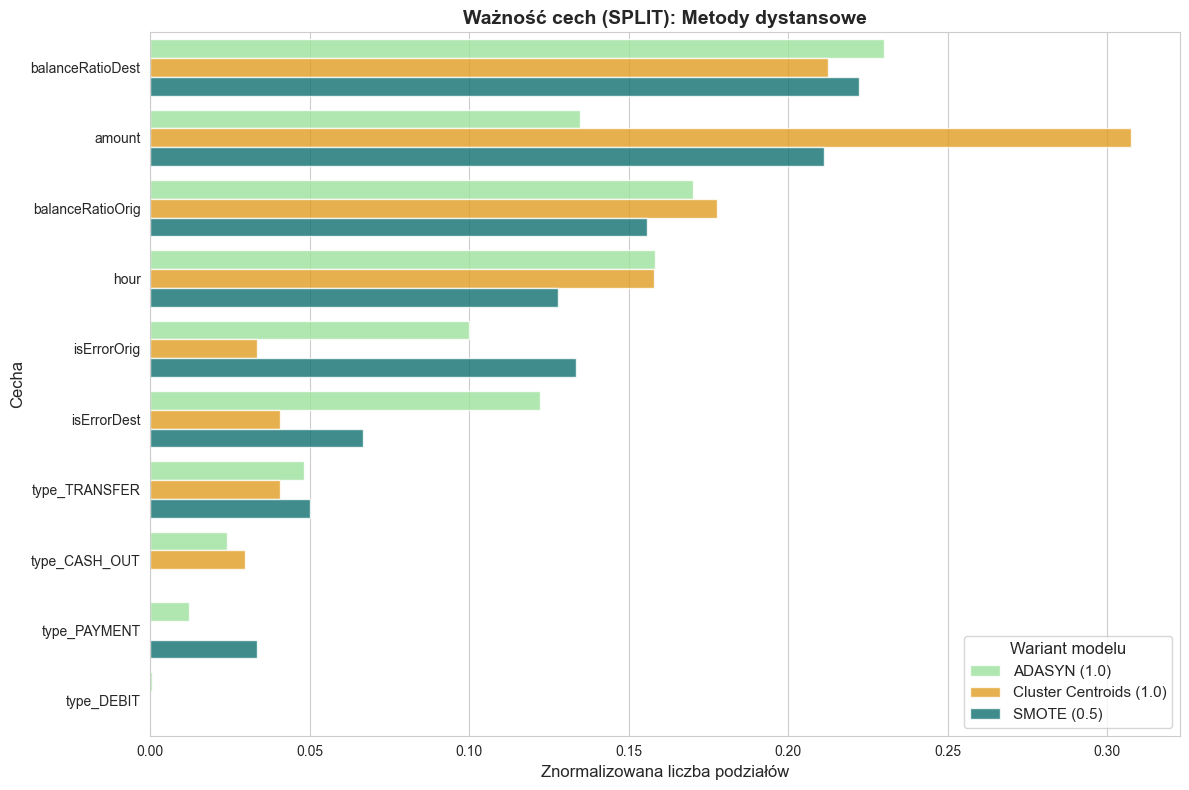

In [17]:
# wykres drugi
df_scaled_split = df_melted_split[df_melted_split["Model"].isin(models_scaled.keys())]
order_scaled_split = (
    df_scaled_split.groupby("Cecha")["Ważność"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_scaled_split,
    x="Ważność",
    y="Cecha",
    hue="Model",  
    order=order_scaled_split,
    palette=["lightgreen", "orange", "teal"],
    alpha=0.8,
)
plt.title("Ważność cech (SPLIT): Metody dystansowe", fontsize=14, fontweight="bold")
plt.xlabel("Znormalizowana liczba podziałów", fontsize=12)
plt.ylabel("Cecha", fontsize=12)
plt.legend(title="Wariant modelu", fontsize=11, title_fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()